In [1]:
import os
import numpy as np
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt

In [2]:
start_year = 2004
end_year = 2004
pred_file = f'../results/{start_year}-{end_year}/hdpsm_nrep10_mratio5_maxsamp50000_drug_reaction_associations.csv'

In [3]:
preds = pd.read_csv(pred_file)
preds['reaction'] = preds['reaction'].str.lower()
preds['mean'] = preds['a']/(preds['a']+preds['b'])
preds['prr_diff'] = np.log(preds['PRR'])-np.log(preds['uncorrected_PRR'])
preds = preds[preds['patient_sex']=='All']
preds = preds.dropna()
preds.head()

,drug,reaction,patient_sex,replicate,a,b,c,d,OR,PRR,PHI,uncorrected_a,uncorrected_b,uncorrected_c,uncorrected_d,uncorrected_OR,uncorrected_PRR,uncorrected_PHI,mean,prr_diff
0,celecoxib,arthritis,All,0.0,19,985,19,3250,3.299492,3.255976,0.059215,36.0,3635.0,545.0,200847.0,3.649782,3.623797,0.017713,0.018924,-0.107030
1,celecoxib,duodenal ulcer haemorrhage,All,0.0,5,999,7,3262,2.332332,2.325697,0.022743,10.0,3661.0,104.0,201288.0,5.286702,5.275025,0.012418,0.004980,-0.818963
2,celecoxib,hypotension,All,0.0,26,978,67,3202,1.270519,1.263513,0.015693,66.0,3605.0,2998.0,198394.0,1.211534,1.207731,0.003380,0.025896,0.045153
3,celecoxib,sleep disorder,All,0.0,5,999,18,3251,0.903960,0.904438,-0.003049,15.0,3656.0,740.0,200652.0,1.112492,1.112032,0.000901,0.004980,-0.206631
4,celecoxib,osteoarthritis,All,0.0,14,990,12,3257,3.838215,3.798639,0.056009,27.0,3644.0,190.0,201202.0,7.846285,7.795931,0.026147,0.013944,-0.718959


In [4]:
# positive controls
fn = '../data/onsides_public_warnings_and_precautions.csv'
positive_df = pd.read_csv(fn)
positive_df['pt_meddra_term'] = positive_df['pt_meddra_term'].str.lower()
positive_df.rename(columns={'pt_meddra_term': 'reaction', 'ingredients_names': 'drug'}, inplace=True)
positive_df['label'] = 1
positive_df.head()

,ingredients_rxcuis,drug,pt_meddra_id,reaction,label
0,321988,escitalopram,10012218,delirium,1
1,1364347,ponatinib,10003668,atrial tachycardia,1
2,4493,fluoxetine,10025197,lymphadenopathy,1
3,4099,"estrogens, conjugated (USP)",10016807,fluid retention,1
4,753340,sapropterin,10037211,psychomotor hyperactivity,1


In [5]:
# merged = pd.merge(preds, positive_df, on=['drug', 'reaction'], how='left')
# merged = merged[merged['replicate']==1]
# merged['label'] = merged['label'].fillna(0)
# merged.head()

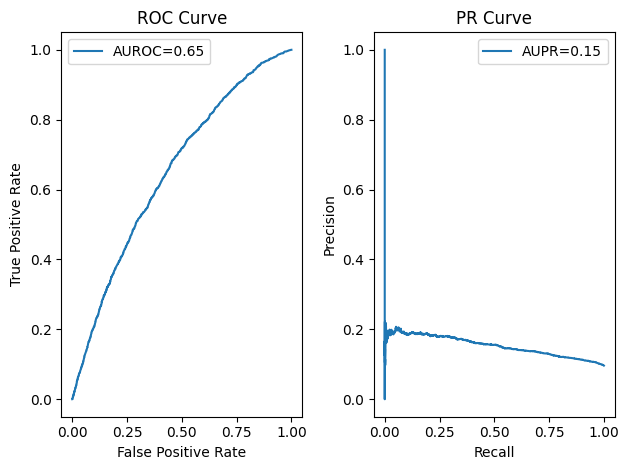

In [ ]:
col = 'mean'
rep = 1

merged = pd.merge(preds, positive_df, on=['drug', 'reaction'], how='left')
merged = merged[merged['replicate']==rep]
merged['label'] = merged['label'].fillna(0)

auroc = metrics.roc_auc_score(merged['label'], merged[col])
aupr = metrics.average_precision_score(merged['label'], merged[col])
fpr, tpr, thresholds = metrics.roc_curve(merged['label'], merged[col], pos_label=1)
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUROC={auroc:.2f}")
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

pr, re, th = metrics.precision_recall_curve(merged['label'], merged[col])
plt.subplot(1,2,2)
plt.plot(re, pr, label=f"AUPR={aupr:.2f}")
plt.title('PR Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')

plt.legend()
plt.tight_layout()
plt.savefig(f'../results/{start_year}-{end_year}/performance_roc_pr_curves_onsides.pdf')


In [ ]:
neg = merged[col][merged['label']==0]
pos = merged[col][merged['label']==1]
neg.mean(), pos.mean()